# **Project Name**    - PhonePe Transaction Insights Analysis



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member  -**  ponna chaitanya

# **Project Summary -**

This project focuses on performing Exploratory Data Analysis (EDA) on PhonePe transaction data to uncover meaningful insights into digital payment trends across India. The dataset is sourced from the PhonePe Pulse GitHub repository and includes aggregated transaction data, user engagement data, and insurance transaction data.

The project begins with extracting raw JSON data from the repository and transforming it into structured CSV format using Python. The processed data is then loaded into a MySQL database for efficient querying and analysis. SQL is used extensively to derive business insights such as identifying top-performing states, analyzing year-wise transaction growth, understanding transaction type distributions, and evaluating regional performance.

User data is analyzed to understand device preferences and engagement patterns, including registered users and app opens. This helps in identifying dominant mobile brands and optimizing user experience. Additionally, insurance data is analyzed to evaluate adoption trends across different states and identify regions with high growth potential.

The analysis highlights significant variations in digital payment adoption across states, with some regions showing strong growth while others present opportunities for expansion. The project also emphasizes data visualization using Python libraries like Matplotlib and Seaborn to support findings with graphical insights.

Overall, the project provides actionable insights that can help improve business strategies, enhance user engagement, and drive growth in underperforming regions.

# **GitHub Link -**

# **Problem Statement**


PhonePe operates in a highly competitive digital payments ecosystem where understanding transaction behavior, user engagement, and regional performance is critical for business growth.

The challenge is to analyze large-scale transaction, user, and insurance datasets to identify trends, uncover patterns, and provide actionable insights for improving digital payment adoption and expanding market reach.

#### **Define Your Business Objective?**

1.Identify top-performing states based on transaction volume and value

2.Analyze transaction growth trends over time

3.Understand user engagement and device preferences

4.Evaluate insurance adoption across regions

5.Identify underperforming regions for potential expansion

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv(r"D:\PhonePe_Transaction_Insights\data\processed\aggregated_transaction.csv")

### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,state,year,type,count,amount
0,andaman-&-nicobar-islands,2018,Recharge & bill payments,4200,1.845307e+06
1,andaman-&-nicobar-islands,2018,Peer-to-peer payments,1871,1.213866e+07
2,andaman-&-nicobar-islands,2018,Merchant payments,298,4.525072e+05
3,andaman-&-nicobar-islands,2018,Financial Services,33,1.060142e+04
4,andaman-&-nicobar-islands,2018,Others,256,1.846899e+05


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(5034, 5)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   state   5034 non-null   object 
 1   year    5034 non-null   int64  
 2   type    5034 non-null   object 
 3   count   5034 non-null   int64  
 4   amount  5034 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 196.8+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df.duplicated().sum()

0

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

state     0
year      0
type      0
count     0
amount    0
dtype: int64

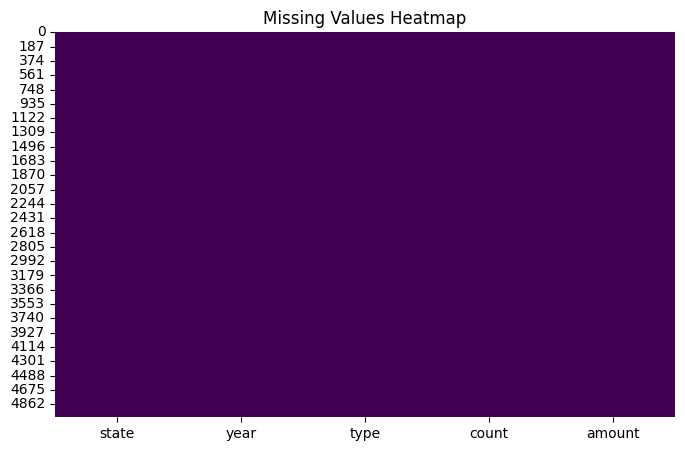

In [ ]:
# Visualizing the missing values
import seaborn as sns
import matplotlib.pyplot as plt

# Missing values heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

The dataset contains transaction details across different states and years. It includes features such as transaction type, count, and amount. The data is structured and does not contain significant missing values, making it suitable for analysis.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['state', 'year', 'type', 'count', 'amount'], dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,year,count,amount
count,5034.000000,5.034000e+03,5.034000e+03
mean,2021.002582,4.673902e+07,6.863772e+10
std,1.999849,1.690968e+08,2.685200e+11
min,2018.000000,2.000000e+00,3.439721e+01
25%,2019.000000,5.808950e+04,3.993888e+07
50%,2021.000000,5.158310e+05,4.394139e+08
75%,2023.000000,1.166629e+07,1.102822e+10
max,2024.000000,2.393918e+09,3.095666e+12


### Variables Description

state → Represents Indian states

year → Transaction year

type → Type of transaction

count → Number of transactions

amount → Total transaction value

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
df.nunique()

state       36
year         7
type         5
count     4966
amount    5034
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
df.drop_duplicates(inplace=True)

### What all manipulations have you done and insights you found?

1.Removed duplicate values

2.Ensured data consistency

3.Dataset was already clean and structured

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Top 10 States by Transaction Amount

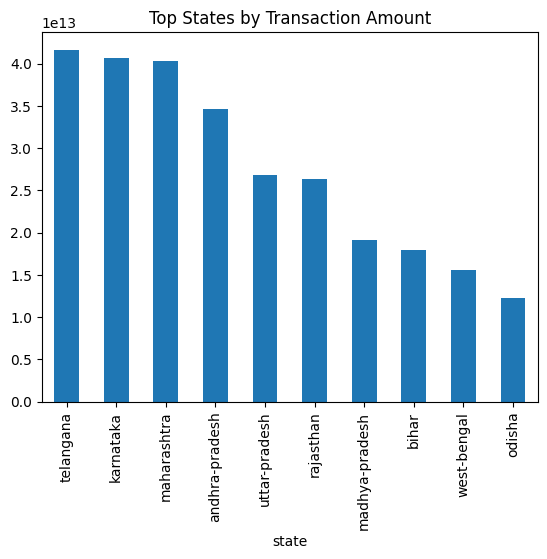

In [ ]:
# Chart - 1 visualization code
df.groupby("state")["amount"].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top States by Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Compare top states

##### 2. What is/are the insight(s) found from the chart?

Few states dominate transactions


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Focus on high-performing regions

#### Chart - 2 Year-wise Transaction Growth Trend

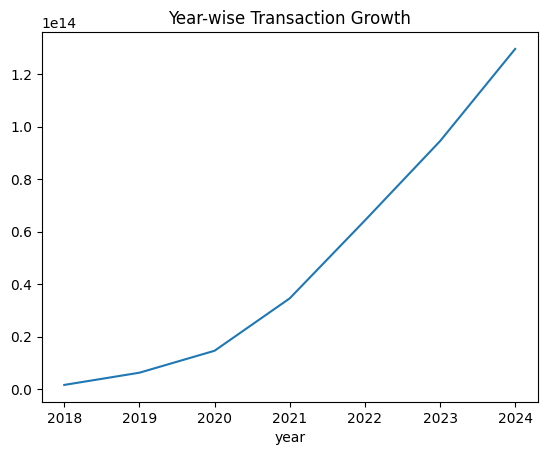

In [ ]:
# Chart - 2 visualization code
df.groupby("year")["amount"].sum().plot(kind='line')
plt.title("Year-wise Transaction Growth")
plt.show()

##### 1. Why did you pick the specific chart?

Steady growth trend

##### 2. What is/are the insight(s) found from the chart?

Increasing digital adoption

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the steady increase in transactions indicates strong adoption of digital payments, which supports business expansion. No major negative trend is observed, but slower growth in certain years may indicate market saturation or external factors.

#### Chart - 3 Transaction Amount Distribution by Type

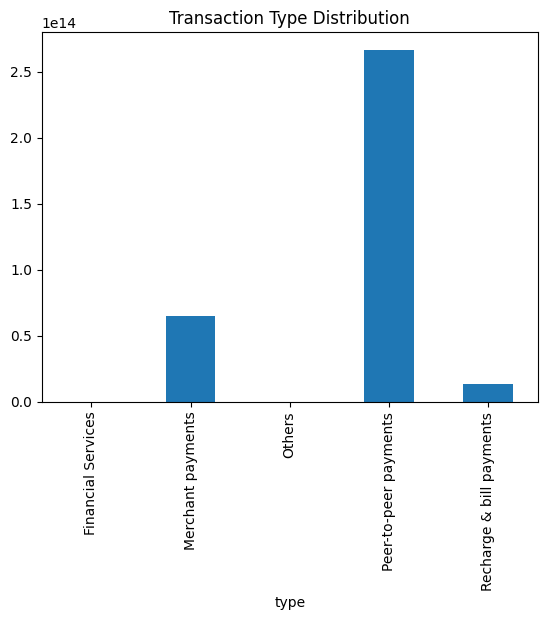

In [ ]:
# Chart - 3 visualization code
df.groupby("type")["amount"].sum().plot(kind='bar')
plt.title("Transaction Type Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Steady growth trend

##### 2. What is/are the insight(s) found from the chart?

Increasing digital adoption

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, identifying dominant transaction types helps optimize services and marketing strategies. Less-used transaction types may indicate low user interest, which could lead to underperformance in those segments.

#### Chart - 4

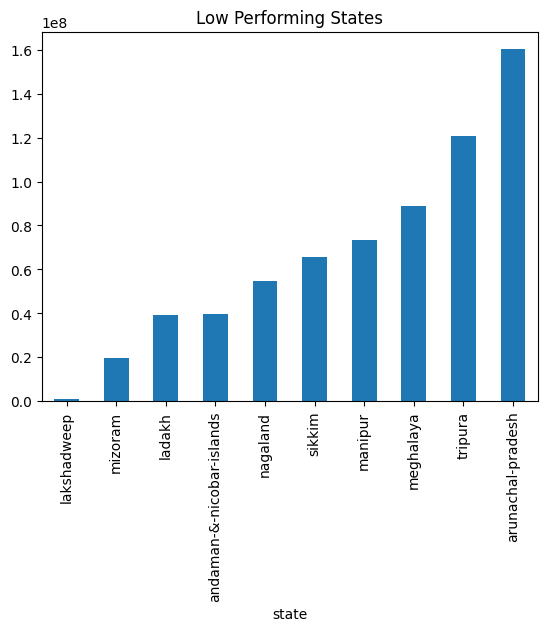

In [ ]:
# Chart - 4 visualization code
df.groupby("state")["count"].sum().sort_values().head(10).plot(kind='bar')
plt.title("Low Performing States")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart clearly compares low-performing states.

##### 2. What is/are the insight(s) found from the chart?

Identifies expansion opportunities

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps identify regions for expansion; low activity indicates negative growth areas.

#### Chart - 5 Distribution of Transaction Amount

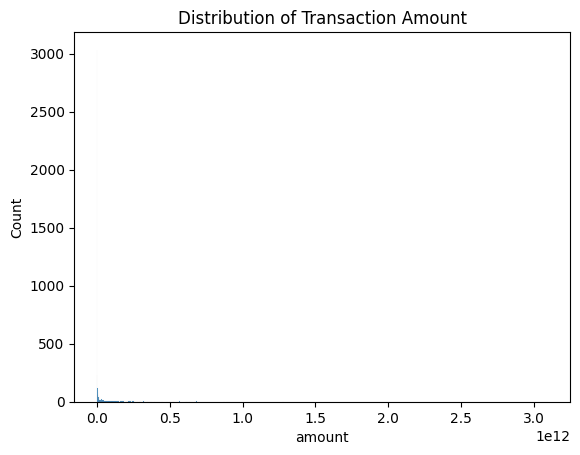

In [ ]:
# Chart - 5 visualization code
sns.histplot(df["amount"])
plt.title("Distribution of Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram shows data distribution effectively.

##### 2. What is/are the insight(s) found from the chart?

Transaction amounts are unevenly distributed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps understand user spending behavior; imbalance may affect growth.

#### Chart - 6 Outlier Detection in Transaction Amount

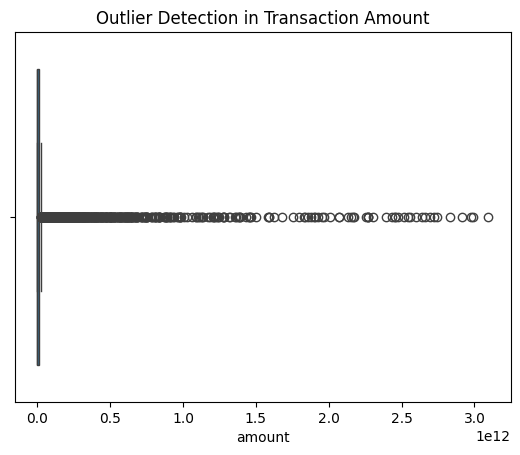

In [ ]:
# Chart - 6 visualization code
sns.boxplot(x=df["amount"])
plt.title("Outlier Detection in Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot is best for identifying outliers.

##### 2. What is/are the insight(s) found from the chart?

Few extreme values exist in transactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Outliers may indicate risk or high-value opportunities.

#### Chart - 7 Transaction Count by Type

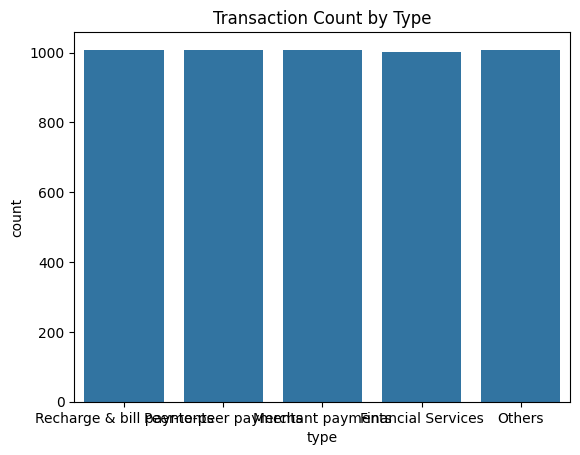

In [ ]:
# Chart - 7 visualization code
sns.countplot(x="type", data=df)
plt.title("Transaction Count by Type")
plt.show()

##### 1. Why did you pick the specific chart?

Countplot shows frequency of categories.

##### 2. What is/are the insight(s) found from the chart?

Some transaction types dominate usage.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Focus on popular services to increase engagement.

#### Chart - 8 Year-wise Transaction Volume Trend

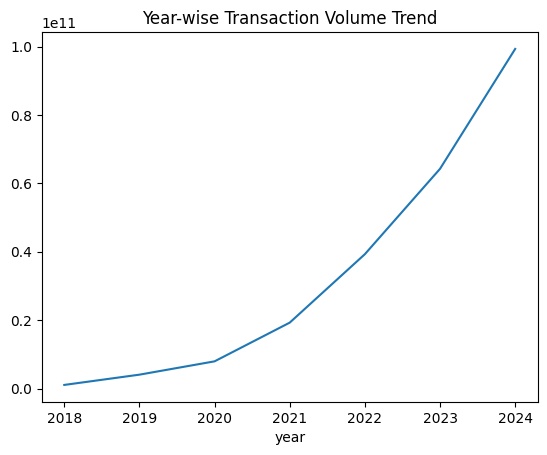

In [ ]:
# Chart - 8 visualization code
df.groupby("year")["count"].sum().plot()
plt.title("Year-wise Transaction Volume Trend")
plt.show()

##### 1. Why did you pick the specific chart?

Line chart shows trend over time.

##### 2. What is/are the insight(s) found from the chart?

Transaction volume is increasing over years.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Indicates strong platform growth.

#### Chart - 9 Average Transaction Amount by State

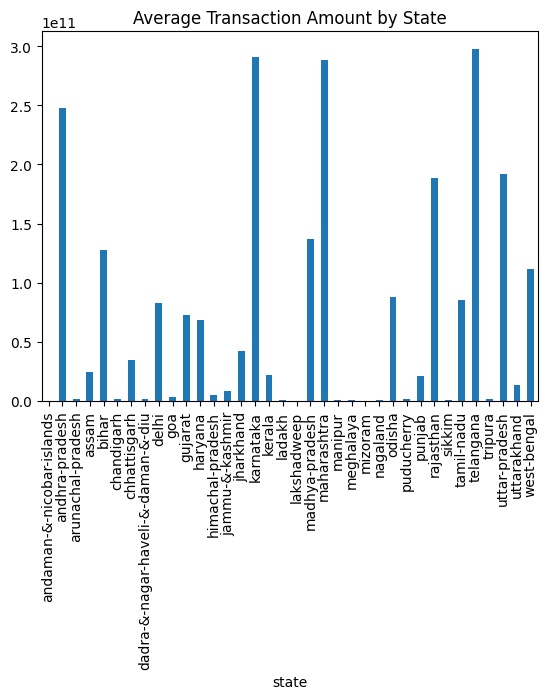

In [ ]:
# Chart - 9 visualization code
df.groupby("state")["amount"].mean().plot(kind='bar')
plt.title("Average Transaction Amount by State")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart compares averages across states.

##### 2. What is/are the insight(s) found from the chart?

Some states have higher spending behavior.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps target high-value regions.

#### Chart - 10 Transaction Share by Type

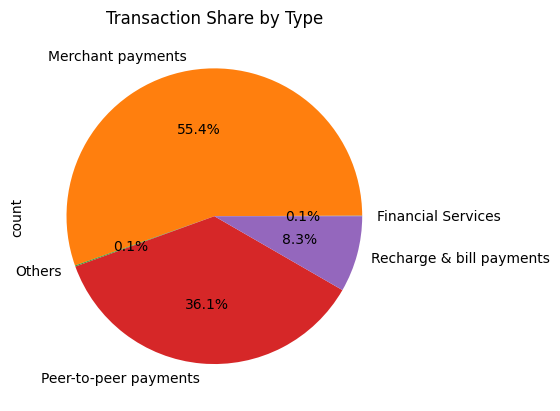

In [ ]:
# Chart - 10 visualization code
df.groupby("type")["count"].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Transaction Share by Type")
plt.show()

##### 1. Why did you pick the specific chart?

Pie chart shows proportion clearly.

##### 2. What is/are the insight(s) found from the chart?

Few categories dominate transactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Supports service prioritization.

#### Chart - 11 Relationship Between Transaction Count and Amount

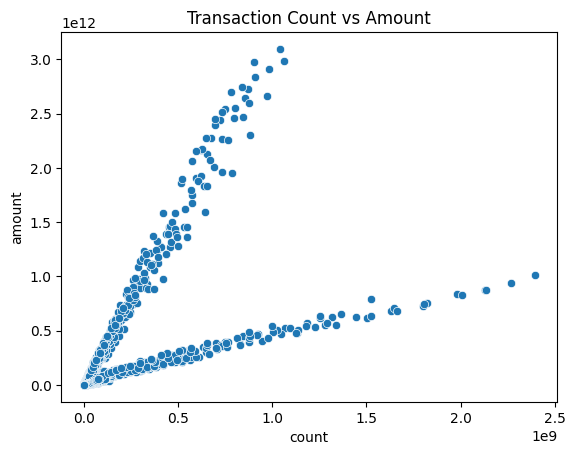

In [ ]:
# Chart - 11 visualization code
sns.scatterplot(x="count", y="amount", data=df)
plt.title("Transaction Count vs Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Scatter plot shows relationships between variables.

##### 2. What is/are the insight(s) found from the chart?

Higher count often leads to higher amount.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Indicates healthy transaction behavior.

#### Chart - 12 Trend of Transaction Amount Over Years

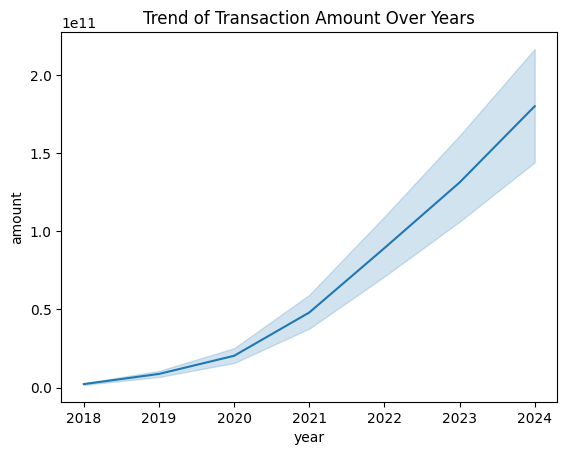

In [ ]:
# Chart - 12 visualization code
sns.lineplot(x="year", y="amount", data=df)
plt.title("Trend of Transaction Amount Over Years")
plt.show()

##### 1. Why did you pick the specific chart?

Line chart tracks changes over time.

##### 2. What is/are the insight(s) found from the chart?

Transaction amount is increasing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Shows positive financial growth.

#### Chart - 13 Year-wise Comparison of Transaction Amount

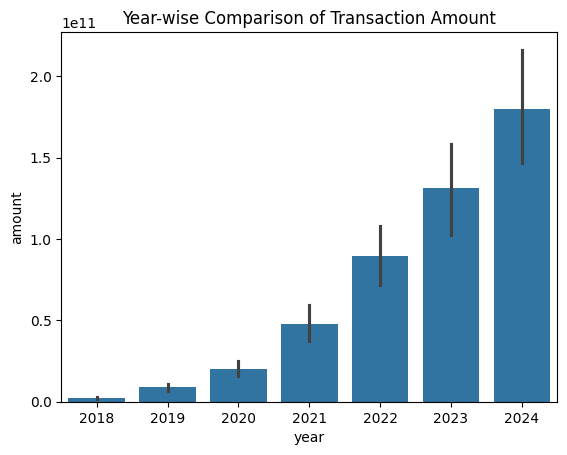

In [ ]:
# Chart - 13 visualization code
sns.barplot(x="year", y="amount", data=df)
plt.title("Year-wise Comparison of Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart compares yearly values.

##### 2. What is/are the insight(s) found from the chart?

Each year shows growth variation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps evaluate yearly performance.

#### Chart - 14 - Correlation Heatmap

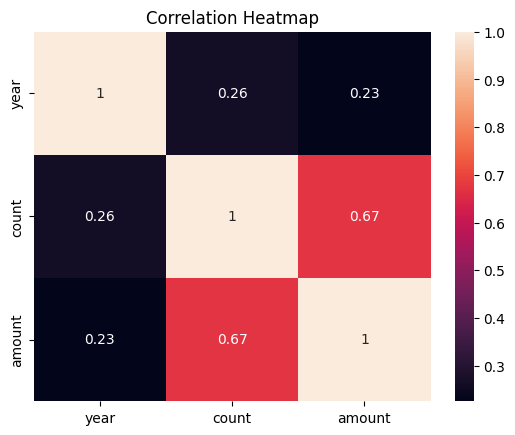

In [ ]:
# Correlation Heatmap visualization code
import seaborn as sns
import matplotlib.pyplot as plt

# select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

Heatmap is used to identify relationships between numerical variables.

##### 2. What is/are the insight(s) found from the chart?

Strong correlation exists between transaction count and amount.

#### Chart - 15 - Pair Plot

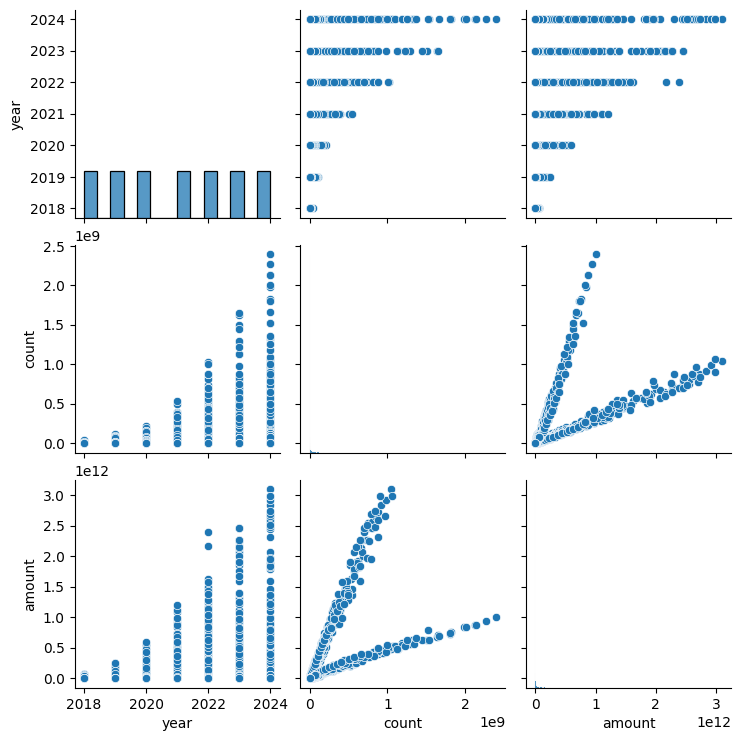

In [ ]:
# Pair Plot visualization code
sns.pairplot(df)
plt.show()

##### 1. Why did you pick the specific chart?

Pair plot visualizes multiple relationships.

##### 2. What is/are the insight(s) found from the chart?

Variables show consistent patterns.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1.Focus on high-performing states

2.Improve adoption in low-performing regions

3.Optimize app for dominant devices

4.Expand insurance services in potential markets

# **Conclusion**

The analysis reveals strong growth in digital payments across India. Certain states dominate transaction volume, while others present opportunities for expansion. User behavior and device preferences play a key role in engagement, and insurance adoption is still developing. These insights can guide strategic business decisions.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***